# **BrainHack 2026**

## Table of contents<a id='toc0_'></a>    

- [Setup](#toc2_)    
  - [Install](#toc2_1_)    
    - [For developers](#toc2_1_1_)    
    - [For users](#toc2_1_2_)    
    - [Optional](#toc2_1_3_)    
  - [Imports](#toc2_2_)    
  - [Overview](#toc2_3_)    
    - [Signal](#toc2_3_1_)    
    - [Pulse](#toc2_3_2_)    
    - [Sequence](#toc2_3_3_)    
    - [System](#toc2_3_4_)    
    - [Simulator](#toc2_3_5_)    
    - [Corrector](#toc2_3_6_)    
    - [Trajector](#toc2_3_7_)    
    - [CompositeDictionary](#toc2_3_8_)    
- [Applications](#toc3_)    
  - [Simulating a single experiment](#toc3_1_)    
    - [Using the `brainhack.simulator.Simulator` class](#toc3_1_1_)    
    - [Using the `brainhack.run.SingleRun` function](#toc3_1_2_)    
      - [Hand parametrized](#toc3_1_2_1_)    
      - [Using a configuration object](#toc3_1_2_2_)    
      - [From the command line](#toc3_1_2_3_)    
    - [Example: Computing derivative maps: MT(s/d)R, ihMT, ihMTR, BP, BPR](#toc3_1_3_)    
      - [Manual Computation](#toc3_1_3_1_)    
      - [Using `brainhack.meta.CompositeSignal`](#toc3_1_3_2_)    
    - [Example: Computing steady-state signals at every readout](#toc3_1_4_)    
      - [Manual computation](#toc3_1_4_1_)    
      - [Using `brainhack.trajector.Trajector`](#toc3_1_4_2_)    
        - [Timing difference using `stable=True`](#toc3_1_4_2_1_)    
        - [Value difference using `stable=True`](#toc3_1_4_2_2_)    
    - [Example: Point Spread Function (PSF)](#toc3_1_5_)    
  - [Simulating many experiments](#toc3_2_)    
    - [Using the `brainhack.run.ManyRuns` function](#toc3_2_1_)    
    - [Example: Computing derivative maps: MT(s/d)R, ihMT, ihMTR, BP, BPR](#toc3_2_2_)    
    - [Example: $\mathrm{B}_1^+$ correction](#toc3_2_3_)    
      - [Manual computation](#toc3_2_3_1_)    
      - [Using `brainhack.corrector.Corrector`](#toc3_2_3_2_)    
  - [Visualization](#toc3_3_)    
    - [Example: $\mathrm{B}_1^+$ correction](#toc3_3_1_)    
      - [1-Dim $\mathrm{B}_1^+$ correction](#toc3_3_1_1_)    
      - [N-Dim $\mathrm{B}_1^+$ correction](#toc3_3_1_2_)    
      - [Real-world data](#toc3_3_1_3_)    
    - [Example: Steady-state signal with respect to readout](#toc3_3_2_)    
    - [Exmple: PSF](#toc3_3_3_)    
  - [Advanced](#toc3_4_)    
    - [Sensivity analysis](#toc3_4_1_)    
      - [Using fixed parameter vectors](#toc3_4_1_1_)    
      - [Using distribution sampling](#toc3_4_1_2_)    
- [Additional Information](#toc4_)    
  - [Configuration files](#toc4_1_)    
    - [Default configurations](#toc4_1_1_)    
      - [3 Teslas](#toc4_1_1_1_)    
      - [7 Teslas](#toc4_1_1_2_)    
    - [Custom configurations](#toc4_1_2_)    
      - [In a live environment](#toc4_1_2_1_)    
      - [Stored on file](#toc4_1_2_2_)    
  - [Loggers](#toc4_2_)    
  - [The `brainhack.meta.CompositeDictionary` class](#toc4_3_)    
  - [Optimizing `brainhack.run.ManyRuns` runtime](#toc4_4_)    
  - [Test suite](#toc4_5_)    
  - [Contributing new features](#toc4_6_)    
    - [Adding new modules](#toc4_6_1_)    
    - [Modifying existing modules](#toc4_6_2_)    
- [Notes](#toc5_)    
- [To do](#toc6_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc2_'></a>[Setup](#toc0_)

## <a id='toc2_1_'></a>[Install](#toc0_)

### <a id='toc2_1_1_'></a>[For developers](#toc0_)
- `NumPy`
- `SciPy`
- `PyYAML`
- `Coverage`

```bash
pip install numpy scipy pyyaml coverage
# or
conda install numpy scipy pyyaml coverage
```

Install `brainhack` in edit mode:
```bash
cd brainhack
pip install -e .
```

### <a id='toc2_1_2_'></a>[For users](#toc0_)
- `NumPy`
- `SciPy`
- `PyYAML`

```bash
pip install numpy scipy pyyaml
# or
conda install numpy scipy pyyaml
```

Install `brainhack` in normal mode:
```bash
cd brainhack
pip install .
```

### <a id='toc2_1_3_'></a>[Optional](#toc0_)
- `Matplotlib`
- `Jupyter`

```bash
pip install matplotlib jupyter
# or
conda install matplotlib jupyter
```

## <a id='toc2_2_'></a>[Imports](#toc0_)

In [64]:
try:  # Basic import example
    from brainhack import (
        Tukey,
        Sequence,
        System,
        Simulator,
        Corrector,
        Trajector,
        Signal,               # Enum (flag)
        CompositeDictionary,  # Utility
        SingleRun,            # Utility
        ManyRuns,             # Utility
    )
    from brainhack.config import default

except ImportError as e:  # If the brainhack package is not installed
    %pip install -e .
    from os import _exit
    _exit(00)

# Additional imports for Applications & later sections
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import yaml as ya

## <a id='toc2_3_'></a>[Overview](#toc0_)

The `brainhack` package aims to provide an interface for simulation and manipulation of (ih)MT signal for varying configurations of MT-preparation pulses, sequences, and biophysical systems. To provide ample space for new features, the package separates each part of the process into different modules:
- MT-preparation pulse classes (e.g., `Tukey`) are declared in the `brainhack.pulse` module,
- the sequence-specifying class `Sequence` is defined in the `brainhack.sequence` module,
- the biophysical system class `System` is in the `brainhack.system` module,
- the simulator class `Simulator` is in the `brainhack.simulator` module,
- the signal correction class `Corrector` is defined in the `brainhack.corrector` module,
- the signal encoding class `Trajector` is defined in the `brainhack.trajector` module,
- some utility features such as the `Signal`, `Angle`, and `Frequency` classes are defined in the `brainhack.meta` module,
- and some utility functions to simplify obtaining results from command line (`SingleRun`) and from batched experiments (`ManyRuns`) are defined in the `brainhack.run` module.

To enhance the user experience, important classes can be directly imported from the `brainhack` namespace. E.g., one can import the `Tukey` class using `from brainhack.pulse import Tukey`, or they can import it using `from brainhack import Tukey` directly. <br>

Below is an object-by-object `Initialization` example of the various classes of the package, with further information on their interplay. The next section shows various example `Applications` of this package, like $\mathrm{B}_1^+$ correction, sensitivity analysis, and visualization. The third and final section contains `Additional Information`, such as defining configuration files for automated analyses and using loggers to manage the package output streams.

### <a id='toc2_3_1_'></a>[Signal](#toc0_)

In [65]:
print(*[f'Signal.{key}' for key in Signal.keys()], sep='\n')

Signal.MT0
Signal.MTs
Signal.MTd_CM
Signal.MTd_ALT
Signal.ihMT_CM
Signal.ihMT_ALT
Signal.BP
Signal.MTsR
Signal.MTdR_CM
Signal.MTdR_ALT
Signal.ihMTR_CM
Signal.ihMTR_ALT
Signal.BPR
Signal.ALL


### <a id='toc2_3_2_'></a>[Pulse](#toc0_)

In [66]:
pulse = Tukey(
    duration=1e-3,  # in s
    shape=.3,
    flipAngle=299,  # in degree
    offset=7000,    # in Hz
)

### <a id='toc2_3_3_'></a>[Sequence](#toc0_)

In [67]:
sequence = Sequence(
    signal=Signal.ALL,
    pulse=pulse,
    N_pulsePerOffset=1,
    N_pulse=6,
    N_burst=10,
    N_adc=96,
    N_dummyADC=0,
    dt_interPulse=1.5e-3,  # in s
    TR_burst=100e-3,       # in s
    dt_lastBurst=9e-3,     # in s
    es=6e-3,               # in s
    tr=20,                 # in s
    readout_flipAngle=6,   # in degree
)

### <a id='toc2_3_4_'></a>[System](#toc0_)

In [68]:
system = System(
    pulse=pulse,
    poolFree_M0=1,
    poolFree_T1=1,                 # in s
    poolFree_T2=0.1,               # in s
    poolFreeBound_exchangeRate=20, # in s^-1
    poolBound_M0=0.1,
    poolBound_T1=1,                # in s 
    poolBound_T1D=0.01,            # in s
    poolBound_T2=1e-5,             # in s
)

### <a id='toc2_3_5_'></a>[Simulator](#toc0_)

In [69]:
simulator = Simulator(
    system=system,
    sequence=sequence,
    output_vectorSlice=slice(1),
    export_readMatrix=True,
)

### <a id='toc2_3_6_'></a>[Corrector](#toc0_)

In [70]:
corrector = Corrector.Simple(simulator=simulator)

### <a id='toc2_3_7_'></a>[Trajector](#toc0_)

In [71]:
trajector = Trajector.CentricOut_Linear(simulator=simulator)

### <a id='toc2_3_8_'></a>[CompositeDictionary](#toc0_)

In [72]:
data = CompositeDictionary({
    Signal.MT0    : [1],
    Signal.MTs    : [2],
    Signal.MTd_CM : [3],
    Signal.MTd_ALT: [4],
})

# <a id='toc3_'></a>[Applications](#toc0_)

In [73]:
# Helper function for `Applications` and later sections
def print_signals(mapping: CompositeDictionary):
    # Printing the mapping for every computed signal
    print('Shape:', mapping[list(mapping.keys())[0]].shape)
    for key in mapping.keys():
        print(str(key.name).rjust(9), mapping[key].tolist(), sep=' = ')

## <a id='toc3_1_'></a>[Simulating a single experiment](#toc0_)

### <a id='toc3_1_1_'></a>[Using the `brainhack.simulator.Simulator` class](#toc0_)

In [74]:
simulator.SteadyState()

{'MT0': array([1.]),
 'MTs': array([0.82673478]),
 'MTd_ALT': array([0.66490904]),
 'MTd_CM': array([0.6533915]),
 'readout': array([[9.77459365e-01, 1.11744793e-01, 0.00000000e+00, 5.98203595e-03],
        [1.11132643e-02, 8.82273171e-01, 0.00000000e+00, 5.98203595e-04],
        [0.00000000e+00, 0.00000000e+00, 5.48811636e-01, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])}

### <a id='toc3_1_2_'></a>[Using the `brainhack.run.SingleRun` function](#toc0_)

#### <a id='toc3_1_2_1_'></a>[Hand parametrized](#toc0_)

In [75]:
SingleRun(
    # Pulse
    pw=1e-3,        # in s
    r_tukey=.3,
    fa_sat=200,     # in degree
    offset=7000,    # in Hz
    # Sequence
    FLAG_Signal='ALL',
    N_altern=1,
    np=4,
    nb=10,
    turbo=80,
    N_dummyADC=3,
    dt=1.5e-3,      # in s
    btr=100e-3,     # in s
    btrlast=1e-3,   # in s
    es=6e-3,        # in s
    tr=3,          # in s
    fa_rage=5,      # in degree
    # System
    M0a=1,
    M0b=0.1,
    T1f=1,          # in s
    T2f=0.1,        # in s
    T1b=1,          # in s 
    T1D=0.01,       # in s
    T2b=1e-5,       # in s
    R=10,           # in s^-1
    # Simulator
    output_fullVector=True,
    export_read=True,
    # Output
    outputDir='./output/',
    filePrefix='',
    export=False,
)

{'MT0': array([0.97320366, 0.09829085, 0.        , 1.        ]),
 'MTs': array([8.59023139e-01, 6.19723931e-02, 2.57624959e-07, 1.00000000e+00]),
 'MTd_ALT': array([ 8.00265008e-01,  4.38997033e-02, -4.44383964e-08,  1.00000000e+00]),
 'MTd_CM': array([0.79585404, 0.04262518, 0.        , 1.        ]),
 'readout': array([[9.84485836e-01, 5.77155166e-02, 0.00000000e+00, 5.98203595e-03],
        [5.74958916e-03, 9.36302447e-01, 0.00000000e+00, 5.98203595e-04],
        [0.00000000e+00, 0.00000000e+00, 5.48811636e-01, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])}

#### <a id='toc3_1_2_2_'></a>[Using a configuration object](#toc0_)

In [76]:
SingleRun(**default['run'])

{'MT0': array([0.97320366, 0.09829085, 0.        , 1.        ]),
 'MTs': array([8.59023139e-01, 6.19723931e-02, 2.57624959e-07, 1.00000000e+00]),
 'MTd_ALT': array([ 8.00265008e-01,  4.38997033e-02, -4.44383964e-08,  1.00000000e+00]),
 'MTd_CM': array([0.79585404, 0.04262518, 0.        , 1.        ]),
 'readout': array([[9.84485836e-01, 5.77155166e-02, 0.00000000e+00, 5.98203595e-03],
        [5.74958916e-03, 9.36302447e-01, 0.00000000e+00, 5.98203595e-04],
        [0.00000000e+00, 0.00000000e+00, 5.48811636e-01, 0.00000000e+00],
        [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00]])}

#### <a id='toc3_1_2_3_'></a>[From the command line](#toc0_)

In [77]:
!python brainhack/run.py ./brainhack/configs/default.yaml

2026-05-22 21:05:11,140 - root - INFO - MT0: [0.9732036610707329, 0.09829085279876042, 0.0, 1.0]
2026-05-22 21:05:11,140 - root - INFO - MTs: [0.8590231386198169, 0.0619723931199686, 2.5762495879556483e-07, 1.0]
2026-05-22 21:05:11,140 - root - INFO - MTd_ALT: [0.8002650081321153, 0.043899703281803405, -4.44383963520833e-08, 1.0]
2026-05-22 21:05:11,140 - root - INFO - MTd_CM: [0.7958540383587304, 0.04262518348196712, 0.0, 1.0]
2026-05-22 21:05:11,140 - root - INFO - readout: [[0.984485836436591, 0.05771551658429958, 0.0, 0.005982035946064735], [0.005749589161890545, 0.9363024474696356, 0.0, 0.0005982035946064736], [0.0, 0.0, 0.5488116360940265, 0.0], [0.0, 0.0, 0.0, 1.0]]


### <a id='toc3_1_3_'></a>[Example: Computing derivative maps: MT(s/d)R, ihMT, ihMTR, BP, BPR](#toc0_)

#### <a id='toc3_1_3_1_'></a>[Manual Computation](#toc0_)

In [78]:
data = SingleRun(**default['run'])

with np.errstate(divide='ignore', invalid='ignore'):
    data['ihMT_CM']   = 2 * (data['MTs'] - data['MTd_CM'])
    data['ihMT_ALT']  = 2 * (data['MTs'] - data['MTd_ALT'])
    data['BP']        = 2 * (data['MTd_ALT'] - data['MTd_CM'])
    data['MTsR']      = 100 * (1 - data['MTs'] / data['MT0'])
    data['MTdR_CM']   = 100 * (1 - data['MTd_CM'] / data['MT0'])
    data['MTdR_ALT']  = 100 * (1 - data['MTd_ALT'] / data['MT0'])
    data['ihMTR_CM']  = 100 * data['ihMT_CM'] / data['MT0']
    data['ihMTR_ALT'] = 100 * data['ihMT_ALT'] / data['MT0']
    data['BPR']       = 100 * data['BP'] / data['MT0']

print_signals(CompositeDictionary(data))

Shape: (4,)
      MT0 = [0.9732036610707329, 0.09829085279876042, 0.0, 1.0]
      MTs = [0.8590231386198169, 0.0619723931199686, 2.5762495879556483e-07, 1.0]
  MTd_ALT = [0.8002650081321153, 0.043899703281803405, -4.44383963520833e-08, 1.0]
   MTd_CM = [0.7958540383587304, 0.04262518348196712, 0.0, 1.0]
  ihMT_CM = [0.12633820052217315, 0.03869441927600295, 5.152499175911297e-07, 0.0]
 ihMT_ALT = [0.11751626097540324, 0.036145379676330386, 6.041267102952962e-07, 0.0]
       BP = [0.008821939546769908, 0.0025490395996725645, -8.88767927041666e-08, 0.0]
     MTsR = [11.732438647558396, 36.949989388279924, -inf, 0.0]
  MTdR_CM = [18.22327944357298, 56.63362126968474, nan, 0.0]
 MTdR_ALT = [17.7700372343799, 55.33693926566783, inf, 0.0]
 ihMTR_CM = [12.981681592029156, 39.367263762809614, inf, 0.0]
ihMTR_ALT = [12.07519717364299, 36.77389975477578, inf, 0.0]
      BPR = [0.9064844183861661, 2.5933640080338294, -inf, 0.0]


#### <a id='toc3_1_3_2_'></a>[Using `brainhack.meta.CompositeSignal`](#toc0_)

In [79]:
data = CompositeDictionary(SingleRun(**default['run']))[Signal.ALL]

print_signals(data)

Shape: (4,)
      MT0 = [0.9732036610707329, 0.09829085279876042, 0.0, 1.0]
      MTs = [0.8590231386198169, 0.0619723931199686, 2.5762495879556483e-07, 1.0]
  MTd_ALT = [0.8002650081321153, 0.043899703281803405, -4.44383963520833e-08, 1.0]
   MTd_CM = [0.7958540383587304, 0.04262518348196712, 0.0, 1.0]
  ihMT_CM = [0.12633820052217315, 0.03869441927600295, 5.152499175911297e-07, 0.0]
 ihMT_ALT = [0.11751626097540324, 0.036145379676330386, 6.041267102952962e-07, 0.0]
       BP = [0.008821939546769908, 0.0025490395996725645, -8.88767927041666e-08, 0.0]
     MTsR = [11.73243864755841, 36.949989388279924, -inf, 0.0]
  MTdR_CM = [18.223279443572977, 56.63362126968474, nan, 0.0]
 MTdR_ALT = [17.770037234379913, 55.33693926566782, inf, 0.0]
 ihMTR_CM = [12.981681592029155, 39.367263762809614, inf, 0.0]
ihMTR_ALT = [12.075197173642989, 36.77389975477578, inf, 0.0]
      BPR = [0.906484418386166, 2.5933640080338294, -inf, 0.0]


### <a id='toc3_1_4_'></a>[Example: Computing steady-state signals at every readout](#toc0_)

#### <a id='toc3_1_4_1_'></a>[Manual computation](#toc0_)

In [80]:
#####
# 2 Ways to compute every readout:
# - Iterative propagation
# - Recomputing the matrix power of the propagator
#####

##### Necessary setup
# Keeping the previous flags state of simulator in memory
tmp = simulator.export_readMatrix, simulator.output_vectorSlice
# Making sure the correct flags are turned on
simulator.export_readMatrix, simulator.output_vectorSlice = True, slice(None)
# Simulating the data
data = simulator.SteadyState()
# Restoring simulator flags to their original value
simulator.export_readMatrix, simulator.output_vectorSlice = tmp

##### Recomputing the matrix power of the propagator
readouts = {key: [] for key in data if key != 'readout'}
for i in range(simulator.sequence.N_adc):
    propagator = np.linalg.matrix_power(data['readout'], i - simulator.sequence.N_dummyADC)
    [readouts[key].append(propagator @ data[key]) for key in data.keys() if key != 'readout']

print_signals(CompositeDictionary(readouts).T[Signal.ALL])

Shape: (4, 96)
      MT0 = [[0.9999999989204701, 0.9946158794866513, 0.989346281068417, 0.9841827413287046, 0.9791178232416097, 0.9741449832216165, 0.9692584563024849, 0.9644531561604549, 0.9597245880616972, 0.9550687730623069, 0.9504821820053672, 0.9459616780478981, 0.9415044666143941, 0.9371080518163935, 0.9327701985017509, 0.9284888992054816, 0.924262345368221, 0.9200889022703553, 0.9159670872012602, 0.9118955504452645, 0.9078730587200583, 0.903898480750393, 0.8999707747009428, 0.8960889772279146, 0.8922521939400894, 0.8884595910870592, 0.8847103883159821, 0.8810038523587224, 0.877339291529089, 0.8737160509254631, 0.8701335082476315, 0.866591070148454, 0.8630881690512437, 0.8596242603726933, 0.8561988200989488, 0.8528113426692201, 0.849461339127214, 0.8461483355058081, 0.8428718714148604, 0.8396314988059415, 0.8364267808911664, 0.8332572911962588, 0.8301226127305356, 0.8270223372587613, 0.8239560646617443, 0.8209234023742634, 0.8179239648903727, 0.8149573733274366, 0.812023255041344

#### <a id='toc3_1_4_2_'></a>[Using `brainhack.trajector.Trajector`](#toc0_)

In [81]:
##### Recomputing the matrix power of the propagator
readouts = Trajector.readouts(simulator=simulator, stable=True)

print_signals(readouts[Signal.ALL])

Shape: (4, 96)
      MT0 = [[0.9999999989204701, 0.9946158794866513, 0.989346281068417, 0.9841827413287046, 0.9791178232416097, 0.9741449832216165, 0.9692584563024849, 0.9644531561604549, 0.9597245880616972, 0.9550687730623069, 0.9504821820053672, 0.9459616780478981, 0.9415044666143941, 0.9371080518163935, 0.9327701985017509, 0.9284888992054816, 0.924262345368221, 0.9200889022703553, 0.9159670872012602, 0.9118955504452645, 0.9078730587200583, 0.903898480750393, 0.8999707747009428, 0.8960889772279146, 0.8922521939400894, 0.8884595910870592, 0.8847103883159821, 0.8810038523587224, 0.877339291529089, 0.8737160509254631, 0.8701335082476315, 0.866591070148454, 0.8630881690512437, 0.8596242603726933, 0.8561988200989488, 0.8528113426692201, 0.849461339127214, 0.8461483355058081, 0.8428718714148604, 0.8396314988059415, 0.8364267808911664, 0.8332572911962588, 0.8301226127305356, 0.8270223372587613, 0.8239560646617443, 0.8209234023742634, 0.8179239648903727, 0.8149573733274366, 0.812023255041344

##### <a id='toc3_1_4_2_1_'></a>[Timing difference using `stable=True`](#toc0_)

In [82]:
print(f'For {simulator.sequence.N_adc} ADC events with {simulator.sequence.N_dummyADC} dummy ADC events:')
print("Stable = False:", end='\t')
%timeit -t -n 100 Trajector.readouts(simulator=simulator, stable=False)
print("Stable = True :", end='\t')
%timeit -t -n 100 Trajector.readouts(simulator=simulator, stable=True)

For 96 ADC events with 0 dummy ADC events:
Stable = False:	953 μs ± 97.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Stable = True :	1.65 ms ± 76.7 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


##### <a id='toc3_1_4_2_2_'></a>[Value difference using `stable=True`](#toc0_)

In [83]:
# We return Signal.ALL to ensure that we precompute all ratio signal
# Otherwise, our quick helper `print_readouts` will compute things like
# [(ihMT_1 - ihMT_2) / (MT0_1 - MT0_2)] instead of [(ihMTR_1 - ihMTR_2)]
print_signals(Trajector.readouts(simulator=simulator, stable=True)[Signal.ALL] - Trajector.readouts(simulator=simulator, stable=False)[Signal.ALL])

Shape: (4, 96)
  MTd_ALT = [[0.0, 0.0, 0.0, 0.0, -1.1102230246251565e-16, 0.0, -1.1102230246251565e-16, 0.0, -2.220446049250313e-16, -2.220446049250313e-16, -2.220446049250313e-16, -1.1102230246251565e-16, -2.220446049250313e-16, -2.220446049250313e-16, -2.220446049250313e-16, -1.1102230246251565e-16, -3.3306690738754696e-16, -3.3306690738754696e-16, -3.3306690738754696e-16, -3.3306690738754696e-16, -4.440892098500626e-16, -4.440892098500626e-16, -4.440892098500626e-16, -3.3306690738754696e-16, -5.551115123125783e-16, -4.440892098500626e-16, -5.551115123125783e-16, -4.440892098500626e-16, -7.771561172376096e-16, -6.661338147750939e-16, -7.771561172376096e-16, -5.551115123125783e-16, -6.661338147750939e-16, -6.661338147750939e-16, -6.661338147750939e-16, -6.661338147750939e-16, -5.551115123125783e-16, -6.661338147750939e-16, -6.661338147750939e-16, -4.440892098500626e-16, -5.551115123125783e-16, -5.551115123125783e-16, -7.771561172376096e-16, -6.661338147750939e-16, -7.771561172376096e-

### <a id='toc3_1_5_'></a>[Example: Point Spread Function (PSF)](#toc0_)

## <a id='toc3_2_'></a>[Simulating many experiments](#toc0_)

### <a id='toc3_2_1_'></a>[Using the `brainhack.run.ManyRuns` function](#toc0_)

In [84]:
sim = simulator.copy()
sim.output_vectorSlice = slice(None)
sim.export_readMatrix = True
data = ManyRuns(
    sim,
    ['poolFree_T1', 'flipAngle'],
    {
        'poolFree_T1': [1.0, 1.5, 2.0],
        'flipAngle': simulator.pulse.flipAngle * np.linspace(.1, 1.5, 36)
    },
    safe=True,
)

print('Readout matrix shape:', data['readout'].shape)
print_signals(CompositeDictionary(data))

Readout matrix shape: (3, 36, 4, 4)
Shape: (4, 3, 36)
  MTd_ALT = [[[0.9891159924943654, 0.9790494463679353, 0.9661807404978799, 0.9509326714074202, 0.9337764470340544, 0.915203239882763, 0.8956977453186605, 0.8757158336395153, 0.8556675992831768, 0.8359062817925753, 0.816722803962976, 0.7983451388119387, 0.7809414159036733, 0.7646255938637886, 0.7494646095232772, 0.7354861010319715, 0.7226860320343547, 0.7110357702231189, 0.700488367459595, 0.690983937341984, 0.6824541286025931, 0.6748257551427925, 0.6680236751280824, 0.6619730219633457, 0.6566008874655413, 0.6518375484838214, 0.6476173168669835, 0.6438790815481639, 0.6405666017622247, 0.6376286022929283, 0.6350187149300113, 0.6326953045760666, 0.6306212132700085, 0.628763450498279, 0.6270928534115365, 0.62558373595369], [0.9876810806484458, 0.9762920403812726, 0.9617388666510315, 0.9445041858705183, 0.9251253939908456, 0.9041619896384321, 0.8821652584237222, 0.8596527140598842, 0.8370887911722183, 0.8148723243382009, 0.79333050395147

### <a id='toc3_2_2_'></a>[Example: Computing derivative maps: MT(s/d)R, ihMT, ihMTR, BP, BPR](#toc0_)

In [85]:
data = CompositeDictionary(data)[Signal.ALL]

print_signals(data)

Shape: (4, 3, 36)
  MTd_ALT = [[[0.9891159924943654, 0.9790494463679353, 0.9661807404978799, 0.9509326714074202, 0.9337764470340544, 0.915203239882763, 0.8956977453186605, 0.8757158336395153, 0.8556675992831768, 0.8359062817925753, 0.816722803962976, 0.7983451388119387, 0.7809414159036733, 0.7646255938637886, 0.7494646095232772, 0.7354861010319715, 0.7226860320343547, 0.7110357702231189, 0.700488367459595, 0.690983937341984, 0.6824541286025931, 0.6748257551427925, 0.6680236751280824, 0.6619730219633457, 0.6566008874655413, 0.6518375484838214, 0.6476173168669835, 0.6438790815481639, 0.6405666017622247, 0.6376286022929283, 0.6350187149300113, 0.6326953045760666, 0.6306212132700085, 0.628763450498279, 0.6270928534115365, 0.62558373595369], [0.9876810806484458, 0.9762920403812726, 0.9617388666510315, 0.9445041858705183, 0.9251253939908456, 0.9041619896384321, 0.8821652584237222, 0.8596527140598842, 0.8370887911722183, 0.8148723243382009, 0.7933305039514743, 0.7727183832200836, 0.7532226650

### <a id='toc3_2_3_'></a>[Example: $\mathrm{B}_1^+$ correction](#toc0_)

#### <a id='toc3_2_3_1_'></a>[Manual computation](#toc0_)

In [86]:
# Initialize variables
flipAngle_nominal = simulator.pulse.flipAngle
relative_range = np.linspace(.1, 1.5, 141)
ihMTR_values = []

# Simulate ihMTR throughout the interpolation range
for value in relative_range:
    simulator.pulse.flipAngle = flipAngle_nominal * value
    out = simulator.SteadyState()
    ihMTR_values.append( 200 * (out['MTs'][0] - out['MTd_CM'][0]) / out['MT0'][0] )
simulator.pulse.flipAngle = flipAngle_nominal

# Generate the interpolator of ihMTR_CM dependency on B1+
interpolator = sp.interpolate.PchipInterpolator(flipAngle_nominal * relative_range, ihMTR_values)

# Correct fake data
FA = np.random.random((2, 2, 3)) * flipAngle_nominal * (max(relative_range) - min(relative_range)) + flipAngle_nominal * min(relative_range)
fake_data = {Signal.ihMTR_CM: interpolator(FA).reshape((2, 2, 3))}
corrected = corrector.apply({'flipAngle': FA}, fake_data)

# Check everything
print('Shape')
print('fake_data:', fake_data[Signal.ihMTR_CM].shape)
print('corrected:', corrected[Signal.ihMTR_CM].shape)

print()

print('Value pairs (original, corrected)')
print(*zip(fake_data[Signal.ihMTR_CM].flatten(), corrected[Signal.ihMTR_CM].flatten()), sep='\n')

Shape
fake_data: (2, 2, 3)
corrected: (2, 2, 3)

Value pairs (original, corrected)
(np.float64(38.757791300307346), np.float64(34.66865583202186))
(np.float64(40.57486287653606), np.float64(34.668655832021855))
(np.float64(37.99435014587735), np.float64(34.66865583202186))
(np.float64(32.44755791293487), np.float64(34.66865583202187))
(np.float64(1.3062592535187076), np.float64(34.66865583202187))
(np.float64(0.3375201240852767), np.float64(34.66865583202186))
(np.float64(6.892007150680267), np.float64(34.66865583202186))
(np.float64(30.33094898461385), np.float64(34.66865583202186))
(np.float64(38.48860363984737), np.float64(34.66865583202187))
(np.float64(40.54910510084162), np.float64(34.66865583202186))
(np.float64(25.578001445351813), np.float64(34.66865583202186))
(np.float64(26.81038368610007), np.float64(34.66865583202186))


#### <a id='toc3_2_3_2_'></a>[Using `brainhack.corrector.Corrector`](#toc0_)

In [87]:
# Generate the interpolator of ihMTR_CM dependency on B1+
interpolant = corrector.interpolants[Signal.ihMTR_CM]

# Correct fake data
FA = np.random.random((2, 2, 3)) * (max(corrector.ranges['flipAngle']) - min(corrector.ranges['flipAngle'])) + min(corrector.ranges['flipAngle'])
fake_data = {Signal.ihMTR_CM: interpolant(FA).reshape((2, 2, 3))}
corrected = corrector.apply({'flipAngle': FA}, fake_data)

# Checking everything
print('Shape')
print('fake_data:', fake_data[Signal.ihMTR_CM].shape)
print('corrected:', corrected[Signal.ihMTR_CM].shape)

print()

print('Value pairs (original, corrected)')
print(*list(zip(fake_data[Signal.ihMTR_CM].flatten(), corrected[Signal.ihMTR_CM].flatten())), sep='\n')

Shape
fake_data: (2, 2, 3)
corrected: (2, 2, 3)

Value pairs (original, corrected)
(np.float64(37.604328065376016), np.float64(34.66865583202187))
(np.float64(30.12252518042455), np.float64(34.66865583202187))
(np.float64(40.125094273675344), np.float64(34.66865583202187))
(np.float64(40.648820870613086), np.float64(34.66865583202187))
(np.float64(38.3638137146152), np.float64(34.66865583202187))
(np.float64(36.67854804716028), np.float64(34.66865583202187))
(np.float64(7.464993842534542), np.float64(34.66865583202187))
(np.float64(22.740358957238733), np.float64(34.66865583202187))
(np.float64(26.170955186441372), np.float64(34.66865583202187))
(np.float64(34.91078584369543), np.float64(34.66865583202187))
(np.float64(4.880000287621017), np.float64(34.66865583202187))
(np.float64(8.927208585936775), np.float64(34.66865583202187))


## <a id='toc3_3_'></a>[Visualization](#toc0_)

### <a id='toc3_3_1_'></a>[Example: $\mathrm{B}_1^+$ correction](#toc0_)

#### <a id='toc3_3_1_1_'></a>[1-Dim $\mathrm{B}_1^+$ correction](#toc0_)

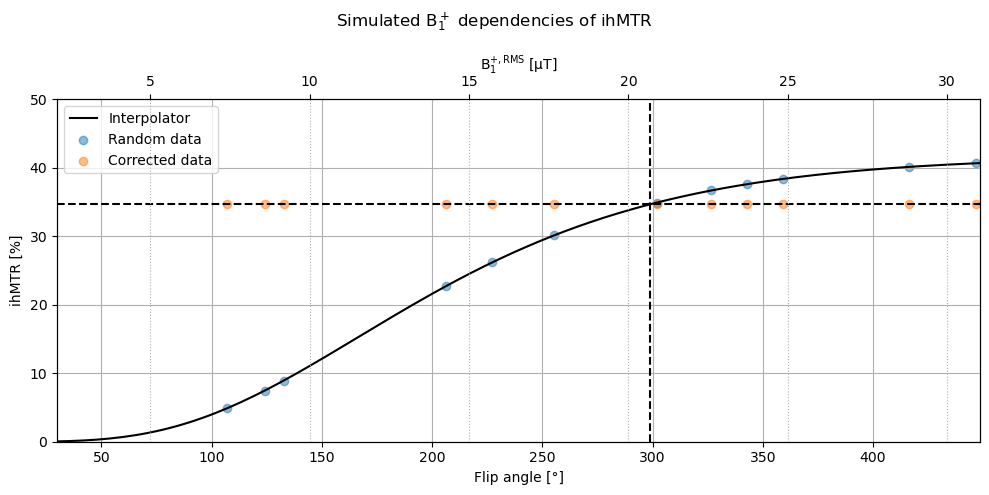

In [88]:
# 1D plotting of ihMTR = f(B1+)
x = corrector.ranges['flipAngle']
xb = (x / corrector.simulator.pulse.flipAngle) * simulator.pulse.b1RMS

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(x, ihMTR_values,'k', label=f'Interpolator')

ax.scatter(FA.flatten(), fake_data[Signal.ihMTR_CM].flatten(), label='Random data', alpha=.5)
ax.scatter(FA.flatten(), corrected[Signal.ihMTR_CM].flatten(), label='Corrected data', alpha=.5)

ax.vlines(corrector.simulator.pulse.flipAngle, 0, 50, 'k', 'dashed')
ax.hlines(corrector.nominals[Signal.ihMTR_CM], min(x), max(x), 'k', 'dashed')

ax.set_xlabel('Flip angle [°]')
ax.set_xlim(min(x), max(x))
ax.set_ylim(0, 50)
ax.set_ylabel('ihMTR [%]')

ax.legend()
ax.grid()

fig.suptitle(r'Simulated $\mathrm{B}_1^+$ dependencies of ihMTR')

ax2 = ax.twiny()
ax2.set_xlim(min(xb) * 1e6, max(xb) * 1e6)
ax2.set_xlabel(r'$\mathrm{B}_1^\mathrm{+,RMS}$ [µT]')
ax2.grid(linestyle='dotted')

fig.tight_layout()
plt.show()

#### <a id='toc3_3_1_2_'></a>[N-Dim $\mathrm{B}_1^+$ correction](#toc0_)

In [89]:
##### Create the data

# Create an N-Dim corrector and retrieve the ihMTR_CM interpolant
nd_corrector = Corrector(simulator, {'poolFree_T1': np.array([1, 1.5, 2.]), 'flipAngle': simulator.pulse.flipAngle * np.linspace(.1, 1.5, 146)})
nominals = nd_corrector.nominals
interp = nd_corrector.interpolants[Signal.ihMTR_CM]

# Some fine tuning for the plot
test_interpolate_for_T1 = 1.25
x = nd_corrector.mesh['flipAngle'].T.squeeze()
ranges = np.vstack([test_interpolate_for_T1 * np.ones_like(x), x]).T

# Creating fake data to correct
shape = (5, 5, 5)
T1 = np.random.random(shape) * (max(nd_corrector.ranges['poolFree_T1']) - min(nd_corrector.ranges['poolFree_T1'])) + min(nd_corrector.ranges['poolFree_T1'])
B1 = np.random.random(shape) * (max(nd_corrector.ranges['flipAngle']) - min(nd_corrector.ranges['flipAngle'])) + min(nd_corrector.ranges['flipAngle'])
params = {'flipAngle': B1, 'poolFree_T1': T1}
data = {Signal.ihMTR_CM: interp(np.vstack([T1.flatten(), B1.flatten()]).T).reshape(shape)}
corrected = nd_corrector.apply(params, data)

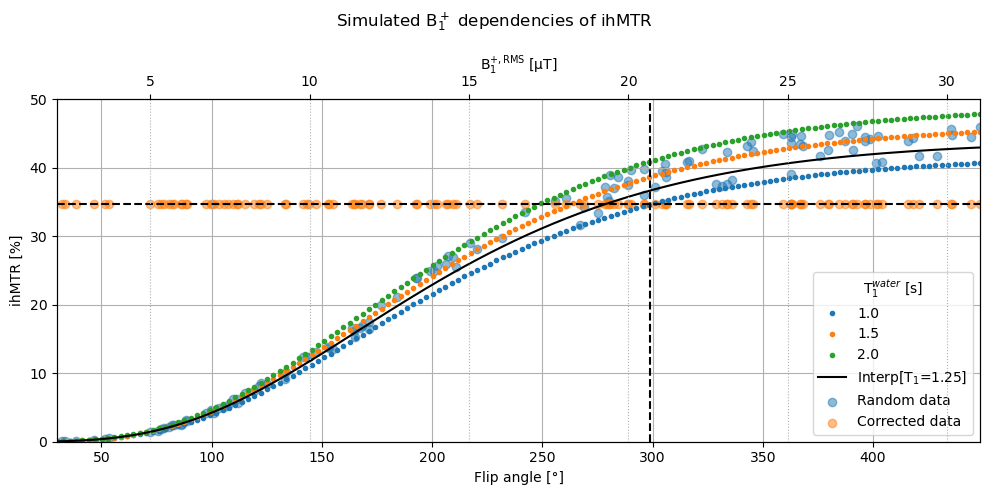

In [90]:
##### Visualize the results

# 2D plotting of ihMTR = f(B1+) for various values of T1_water
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(x, nd_corrector.simulated[Signal.ihMTR_CM].T, '.', label=nd_corrector.ranges['poolFree_T1'])
ax.plot(x, interp(ranges), color='k', label=r'Interp[$\mathrm{T}_1$=' + f'{test_interpolate_for_T1}]')

ax.scatter(B1.flatten(), data[Signal.ihMTR_CM].flatten(), label='Random data', alpha=.5)
ax.scatter(B1.flatten(), corrected[Signal.ihMTR_CM].flatten(), label='Corrected data', alpha=.5)

ax.vlines(simulator.pulse.flipAngle, 0, 50, 'k', 'dashed')
ax.hlines(nominals[Signal.ihMTR_CM], min(nd_corrector.ranges['flipAngle']), max(nd_corrector.ranges['flipAngle']), 'k', 'dashed')

ax.legend(title=r'$\mathrm{T}_1^{water}$ [s]')
ax.set_xlabel('Flip angle [°]')
ax.set_xlim(min(nd_corrector.ranges['flipAngle']), max(nd_corrector.ranges['flipAngle']))

ax.set_ylim(0, 50)
ax.set_ylabel('ihMTR [%]')

ax.grid()

ax2 = ax.twiny()
ax2.set_xlim(.1e6 * simulator.pulse.b1RMS, 1.5e6 * simulator.pulse.b1RMS)
ax2.set_xlabel(r'$\mathrm{B}_1^\mathrm{+,RMS}$ [µT]')
ax2.grid(linestyle='dotted')

fig.suptitle(r'Simulated $\mathrm{B}_1^+$ dependencies of ihMTR')
fig.tight_layout()
plt.show()

#### <a id='toc3_3_1_3_'></a>[Real-world data](#toc0_)

In [100]:
# Preparing variables for correction of real-world data
with open('./examples/example_data_config.yaml') as file:
    real_conf = ya.safe_load(file)

real_pulse = Tukey(**real_conf['pulse'])
real_seq = Sequence(Signal.ihMTR_CM, real_pulse, **real_conf['sequence'])
real_sys = System(real_pulse, **real_conf['system'])
real_sim = Simulator(real_sys, real_seq, export_readMatrix=False, output_vectorSlice=slice(1))

real_data = sp.io.loadmat('./examples/example_data.mat')
real_params = {
    'axial'   : {
        'mask'       : real_data['axial']['mask'][0, 0],
        'flipAngle'  : real_data['axial']['flipAngle'][0, 0],
        'poolFree_T1': real_data['axial']['poolFree_T1'][0, 0],
    },
    'sagittal': {
        'mask'       : real_data['sagittal']['mask'][0, 0],
        'flipAngle'  : real_data['sagittal']['flipAngle'][0, 0],
        'poolFree_T1': real_data['sagittal']['poolFree_T1'][0, 0],
    },
    'coronal' : {
        'mask'       : real_data['coronal']['mask'][0, 0],
        'flipAngle'  : real_data['coronal']['flipAngle'][0, 0],
        'poolFree_T1': real_data['coronal']['poolFree_T1'][0, 0],
    },
}
real_ihMTR = {
    'axial'   : {Signal.ihMTR_CM: real_data['axial']['ihMTR_CM'][0, 0]},
    'sagittal': {Signal.ihMTR_CM: real_data['sagittal']['ihMTR_CM'][0, 0]},
    'coronal' : {Signal.ihMTR_CM: real_data['coronal']['ihMTR_CM'][0, 0]},
}

real_cor1D = Corrector.Simple(real_sim)
real_cor2D = Corrector(real_sim, ranges={'flipAngle': real_pulse.flipAngle * np.linspace(.1, 1.5, 141), 'poolFree_T1': np.arange(1, 4102, 100)})

real_axial    = real_cor1D.apply(real_params['axial'], real_ihMTR['axial'])
real_sagittal = real_cor1D.apply(real_params['sagittal'], real_ihMTR['sagittal'])
real_coronal  = real_cor1D.apply(real_params['coronal'], real_ihMTR['coronal'])

real_cor1D_data = {
    'axial'   : real_axial,
    'sagittal': real_sagittal,
    'coronal' : real_coronal,
}

real_axial    = real_cor2D.apply(real_params['axial'], real_ihMTR['axial'])
real_sagittal = real_cor2D.apply(real_params['sagittal'], real_ihMTR['sagittal'])
real_coronal  = real_cor2D.apply(real_params['coronal'], real_ihMTR['coronal'])

real_cor2D_data = {
    'axial'   : real_axial,
    'sagittal': real_sagittal,
    'coronal' : real_coronal,
}

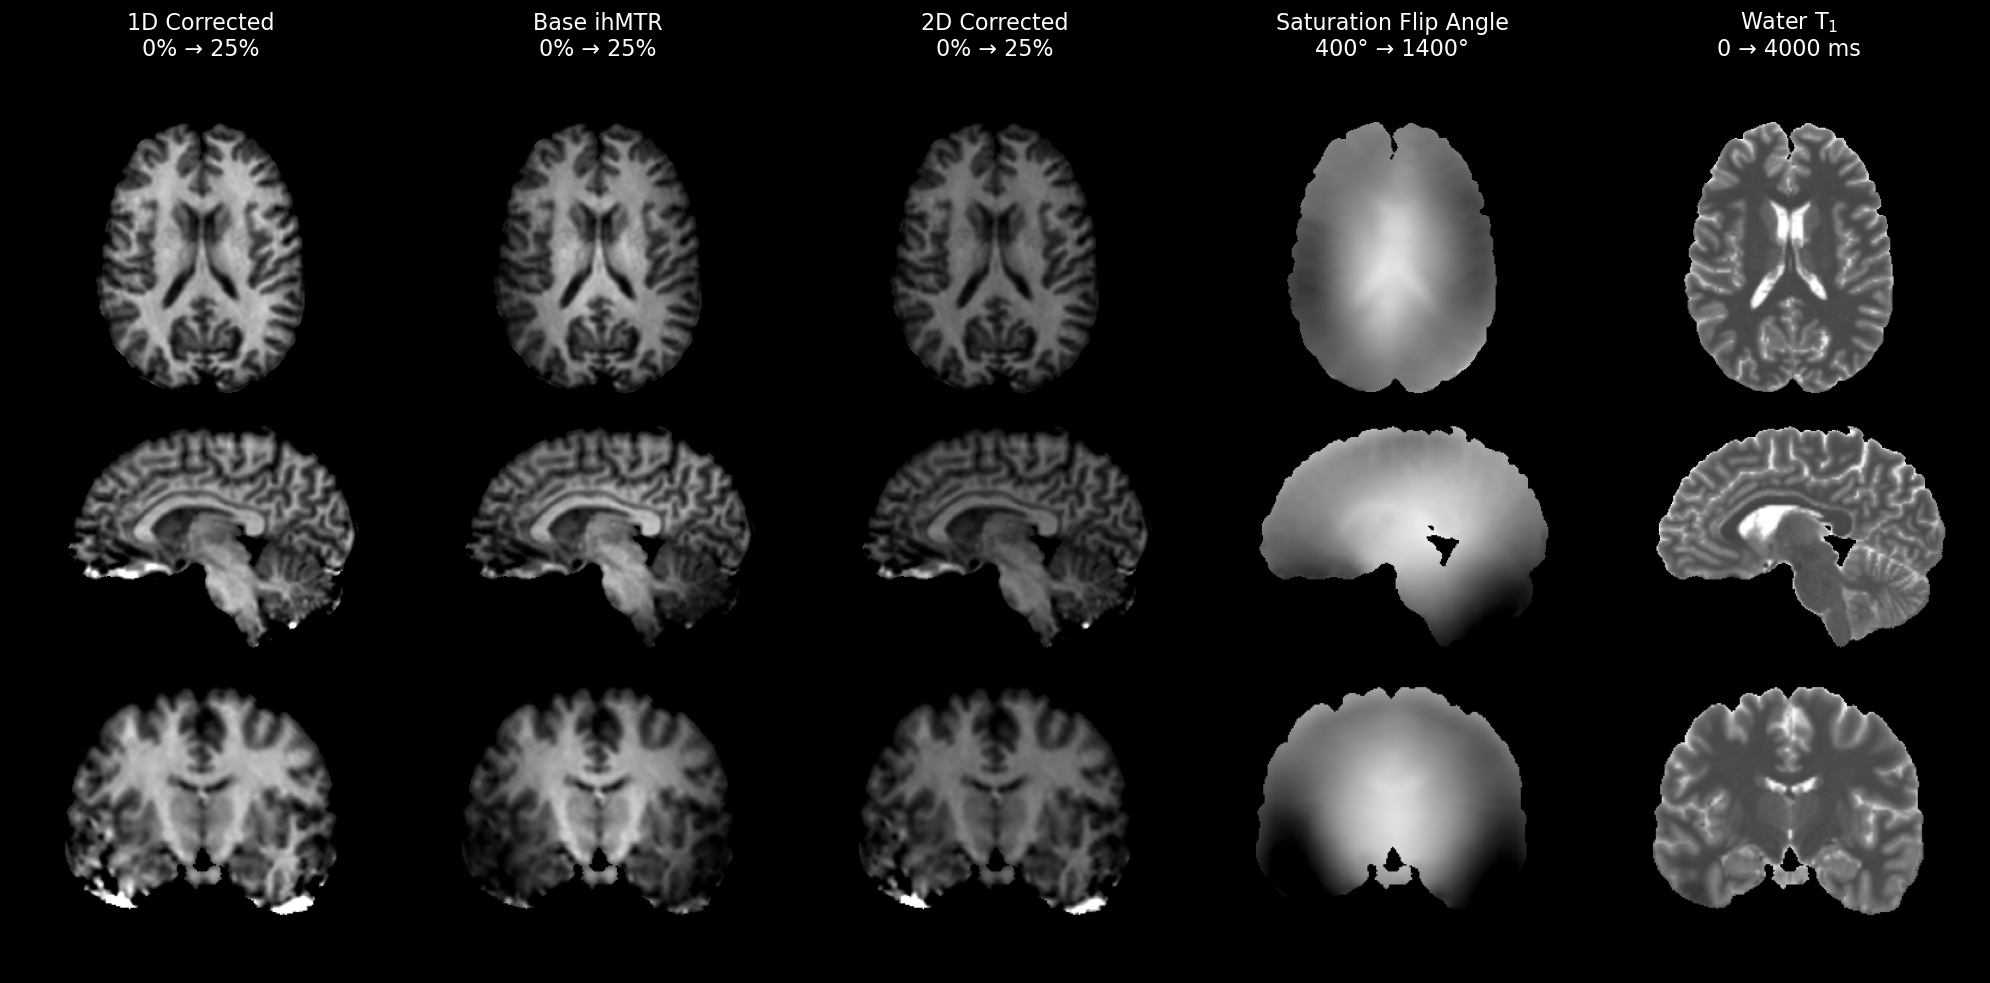

In [101]:
fig, ax = plt.subplots(3, 5, figsize=(20, 10), facecolor='k')
ax = ax.flatten()

c0_0 = ax[0 + 0].imshow(real_cor1D_data['axial'][Signal.ihMTR_CM], cmap='gray', vmin=0, vmax=25)
c0_1 = ax[0 + 1].imshow(real_ihMTR['axial'][Signal.ihMTR_CM], cmap='gray', vmin=0, vmax=25)
c0_2 = ax[0 + 2].imshow(real_cor2D_data['axial'][Signal.ihMTR_CM], cmap='gray', vmin=0, vmax=25)
c0_3 = ax[0 + 3].imshow(real_params['axial']['flipAngle'], cmap='gray', vmin=450, vmax=1400)
c0_4 = ax[0 + 4].imshow(real_params['axial']['poolFree_T1'], cmap='gray', vmin=0, vmax=4000)

c5_0 = ax[5 + 0].imshow(real_cor1D_data['sagittal'][Signal.ihMTR_CM], cmap='gray', vmin=0, vmax=25)
c5_1 = ax[5 + 1].imshow(real_ihMTR['sagittal'][Signal.ihMTR_CM], cmap='gray', vmin=0, vmax=25)
c5_2 = ax[5 + 2].imshow(real_cor2D_data['sagittal'][Signal.ihMTR_CM], cmap='gray', vmin=0, vmax=25)
c5_3 = ax[5 + 3].imshow(real_params['sagittal']['flipAngle'], cmap='gray', vmin=450, vmax=1400)
c5_4 = ax[5 + 4].imshow(real_params['sagittal']['poolFree_T1'], cmap='gray', vmin=0, vmax=4000)

c10_0 = ax[10 + 0].imshow(real_cor1D_data['coronal'][Signal.ihMTR_CM], cmap='gray', vmin=0, vmax=25)
c10_1 = ax[10 + 1].imshow(real_ihMTR['coronal'][Signal.ihMTR_CM], cmap='gray', vmin=0, vmax=25)
c10_2 = ax[10 + 2].imshow(real_cor2D_data['coronal'][Signal.ihMTR_CM], cmap='gray', vmin=0, vmax=25)
c1032 = ax[10 + 3].imshow(real_params['coronal']['flipAngle'], cmap='gray', vmin=450, vmax=1400)
c1042 = ax[10 + 4].imshow(real_params['coronal']['poolFree_T1'], cmap='gray', vmin=0, vmax=4000)

ax[0 + 0].set_title('1D Corrected\n0% → 25%', color='white', fontsize=16)
ax[0 + 1].set_title('Base ihMTR\n0% → 25%'.center(12), color='white', fontsize=16)
ax[0 + 2].set_title('2D Corrected\n0% → 25%', color='white', fontsize=16)
ax[0 + 3].set_title('Saturation Flip Angle\n400° → 1400°'.center(12), color='white', fontsize=16)
ax[0 + 4].set_title(r'Water $\mathrm{T}_1$' '\n0 → 4000 ms'.center(12), color='white', fontsize=16)

[axis.axis('off') for axis in ax]

fig.subplots_adjust(wspace=None, hspace=-.4)
fig.tight_layout()
plt.show()

### <a id='toc3_3_2_'></a>[Example: Steady-state signal with respect to readout](#toc0_)

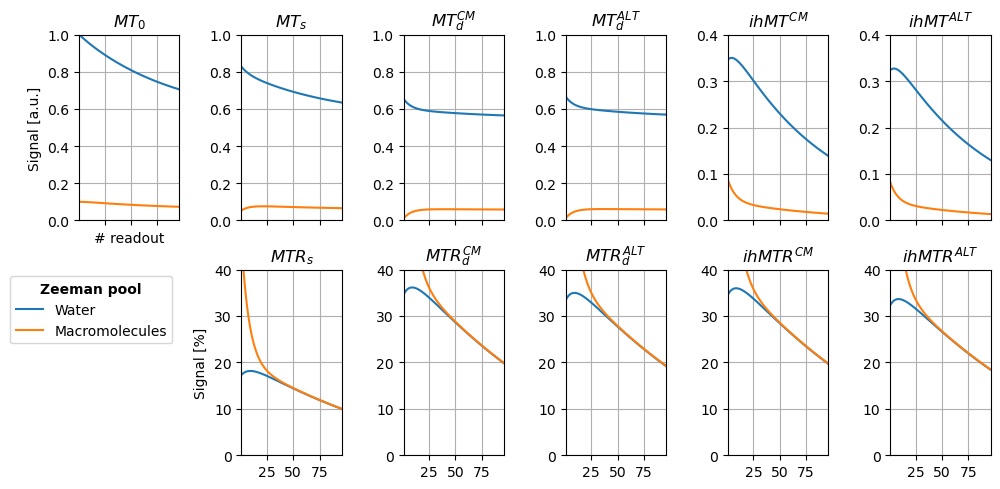

In [94]:
# Generating the data
readouts = Trajector.readouts(simulator=simulator, stable=True)

# Generating the visuals
x = np.array(range(1, simulator.sequence.N_adc + 1))
slices = slice(0, 2)  # Show Zeeman Water and Zeeman Macromolecules only

with np.errstate(divide='ignore', invalid='ignore'):
    fig, axes = plt.subplots(2, 6, sharex=True, figsize=(10, 5))
    axes = axes.flatten()

    axes[0].set_title("$MT_0$")
    axes[0].grid()
    axes[0].set_ylim(0, 1)
    lines = axes[0].plot(x, readouts[Signal.MT0][slices, :].T)
    axes[0].set_xlim(1, simulator.sequence.N_adc)
    axes[0].set_xlabel('# readout')
    axes[0].set_ylabel('Signal [a.u.]')
    axes[0 + 6].set_axis_off()

    axes[1].set_title("$MT_s$")
    axes[1].grid()
    axes[1].set_ylim(0, 1)
    axes[1].plot(x, readouts[Signal.MTs][slices, :].T)
    axes[1 + 6].set_title("$MTR_s$")
    axes[1 + 6].grid()
    axes[1 + 6].set_ylim(0, 40)
    axes[1 + 6].set_ylabel('Signal [%]')
    axes[1 + 6].plot(x, readouts[Signal.MTsR][slices, :].T)

    axes[2].set_title("$MT_d^{CM}$")
    axes[2].grid()
    axes[2].set_ylim(0, 1)
    axes[2].plot(x, readouts[Signal.MTd_CM][slices, :].T)
    axes[2 + 6].set_title("$MTR_d^{CM}$")
    axes[2 + 6].grid()
    axes[2 + 6].set_ylim(0, 40)
    axes[2 + 6].plot(x, readouts[Signal.MTdR_CM][slices, :].T)

    axes[3].set_title("$MT_d^{ALT}$")
    axes[3].grid()
    axes[3].set_ylim(0, 1)
    axes[3].plot(x, readouts[Signal.MTd_ALT][slices, :].T)
    axes[3 + 6].set_title("$MTR_d^{ALT}$")
    axes[3 + 6].grid()
    axes[3 + 6].set_ylim(0, 40)
    axes[3 + 6].plot(x, readouts[Signal.MTdR_ALT][slices, :].T)

    axes[4].set_title("$ihMT^{CM}$")
    axes[4].grid()
    axes[4].set_ylim(0, .40)
    axes[4].plot(x, readouts[Signal.ihMT_CM][slices, :].T)
    axes[4 + 6].set_title("$ihMTR^{CM}$")
    axes[4 + 6].grid()
    axes[4 + 6].set_ylim(0, 40)
    axes[4 + 6].plot(x, readouts[Signal.ihMTR_CM][slices, :].T)

    axes[5].set_title("$ihMT^{ALT}$")
    axes[5].grid()
    axes[5].set_ylim(0, .40)
    axes[5].plot(x, readouts[Signal.ihMT_ALT][slices, :].T)
    axes[5 + 6].set_title("$ihMTR^{ALT}$")
    axes[5 + 6].grid()
    axes[5 + 6].set_ylim(0, 40)
    axes[5 + 6].plot(x, readouts[Signal.ihMTR_ALT][slices, :].T)

    axes[0 + 6].legend(handles=lines, labels=['Water', 'Macromolecules'], title='Zeeman pool', title_fontproperties={'weight':'bold'})
    plt.tight_layout()
    plt.show()

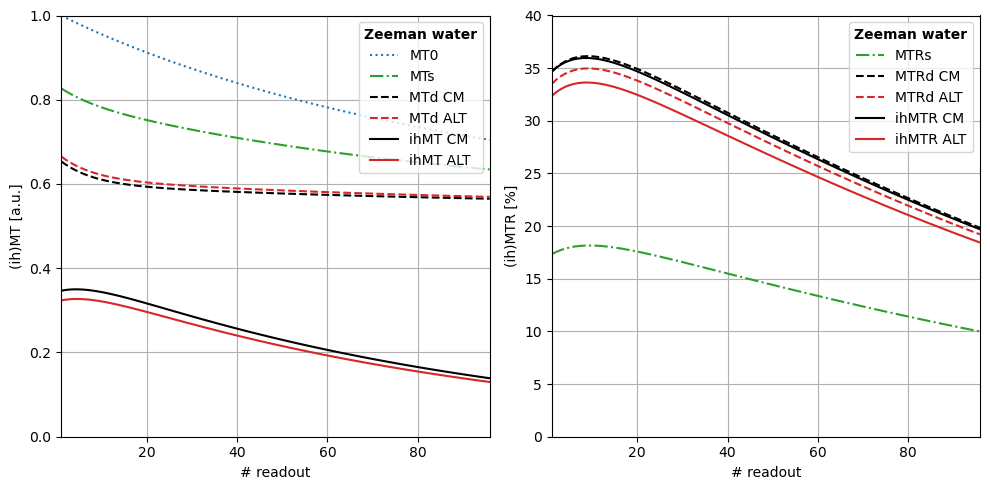

In [95]:
# Generating the data
readouts = Trajector.readouts(simulator=simulator, stable=True)

# Generating the visuals
x = np.array(range(1, simulator.sequence.N_adc + 1))
slices = slice(0, 2)  # Show Zeeman Water and Zeeman Macromolecules only

with np.errstate(divide='ignore', invalid='ignore'):
    fig, axes = plt.subplots(1, 2, sharex=True, figsize=(10, 5))
    axes = axes.flatten()

    axes[0].plot(x, readouts[Signal.MT0][0], color='C0', linestyle='dotted', label='MT0')
    axes[0].plot(x, readouts[Signal.MTs][0], color='C2', linestyle='-.', label='MTs')
    axes[0].plot(x, readouts[Signal.MTd_CM][0], color='k', linestyle='--', label='MTd CM')
    axes[0].plot(x, readouts[Signal.MTd_ALT][0], color='C3', linestyle='--', label='MTd ALT')
    axes[0].plot(x, readouts[Signal.ihMT_CM][0], color='k', linestyle='-', label='ihMT CM')
    axes[0].plot(x, readouts[Signal.ihMT_ALT][0], color='C3', linestyle='-', label='ihMT ALT')

    axes[1].plot(x, readouts[Signal.MTsR][0], color='C2', linestyle='-.', label='MTRs')
    axes[1].plot(x, readouts[Signal.MTdR_CM][0], color='k', linestyle='--', label='MTRd CM')
    axes[1].plot(x, readouts[Signal.MTdR_ALT][0], color='C3', linestyle='--', label='MTRd ALT')
    axes[1].plot(x, readouts[Signal.ihMTR_CM][0], color='k', linestyle='-', label='ihMTR CM')
    axes[1].plot(x, readouts[Signal.ihMTR_ALT][0], color='C3', linestyle='-', label='ihMTR ALT')

    axes[0].legend(title='Zeeman water', title_fontproperties={'weight':'bold'}, )
    axes[0].grid()
    axes[0].set_xlabel('# readout')
    axes[0].set_xlim(1, simulator.sequence.N_adc)
    axes[0].set_ylabel('(ih)MT [a.u.]')
    axes[0].set_ylim(0, 1)

    axes[1].legend(title='Zeeman water', title_fontproperties={'weight':'bold'}, )
    axes[1].grid()
    axes[1].set_xlabel('# readout')
    axes[1].set_xlim(1, simulator.sequence.N_adc)
    axes[1].set_ylabel('(ih)MTR [%]')
    axes[1].set_ylim(0, 40)

    plt.tight_layout()
    plt.show()

### <a id='toc3_3_3_'></a>[Exmple: PSF](#toc0_)

## <a id='toc3_4_'></a>[Advanced](#toc0_)

### <a id='toc3_4_1_'></a>[Sensivity analysis](#toc0_)

#### <a id='toc3_4_1_1_'></a>[Using fixed parameter vectors](#toc0_)

#### <a id='toc3_4_1_2_'></a>[Using distribution sampling](#toc0_)

# <a id='toc4_'></a>[Additional Information](#toc0_)

## <a id='toc4_1_'></a>[Configuration files](#toc0_)

### <a id='toc4_1_1_'></a>[Default configurations](#toc0_)

#### <a id='toc4_1_1_1_'></a>[3 Teslas](#toc0_)

In [96]:
for key, val in default.items():
    print(f'\033[1m{key}\033[0m')
    for kkey, vval in val.items():
        if type(vval) != dict:
            print(str(kkey).rjust(len('disable_existing_loggers')), ':', repr(vval))
        else:
            print(f'\t\033[1m{kkey}\033[0m')
            for kkkey, vvval in vval.items():
                print('\t\t', kkkey, repr(vvval))
    print()

run
                      pw : 0.001
                 r_tukey : 0.3
                  fa_sat : 200
                  offset : 7000
             FLAG_Signal : 'ALL'
                N_altern : 1
                      np : 4
                      nb : 10
                   turbo : 80
              N_dummyADC : 3
                      dt : 0.0015
                     btr : 0.1
                 btrlast : 0.001
                      es : 0.006
                      tr : 3
                 fa_rage : 5
                     M0a : 1
                     M0b : 0.1
                     T1f : 1
                     T2f : 0.1
                     T1b : 1
                     T1D : 0.01
                     T2b : 1e-05
                       R : 10
             export_read : True
       output_fullVector : True
               outputDir : './output/'
              filePrefix : ''
                  export : True

log
                 version : 1
disable_existing_loggers : False
	formatters
		 standard 

#### <a id='toc4_1_1_2_'></a>[7 Teslas](#toc0_)

### <a id='toc4_1_2_'></a>[Custom configurations](#toc0_)

#### <a id='toc4_1_2_1_'></a>[In a live environment](#toc0_)

#### <a id='toc4_1_2_2_'></a>[Stored on file](#toc0_)

## <a id='toc4_2_'></a>[Loggers](#toc0_)

## <a id='toc4_3_'></a>[The `brainhack.meta.CompositeDictionary` class](#toc0_)

## <a id='toc4_4_'></a>[Optimizing `brainhack.run.ManyRuns` runtime](#toc0_)

## <a id='toc4_5_'></a>[Test suite](#toc0_)


In [97]:
try:
    import coverage
except ImportError as e:
    %pip install coverage

!./run_tests.sh

.ss...............EEF.EE.EE.FEE.................EFE......s.....................sss...
ERROR: test_run_SingleRun_ALT_noExport (tests.test_run.TestRun_withoutExport.test_run_SingleRun_ALT_noExport)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "/home/tanderson/git/brainhack/tests/test_run.py", line 169, in test_run_SingleRun_ALT_noExport
    output = check_output([
        'python',
        str(Path(__file__).parents[1] / 'brainhack' / 'run.py'),
        str(Path(DEFAULT['run']['outputDir']) / 'config.yaml'),
    ], stderr=STDOUT)
  File "/home/tanderson/miniconda3/envs/brainhack/lib/python3.14/subprocess.py", line 472, in check_output
    return run(*popenargs, stdout=PIPE, timeout=timeout, check=True,
           ~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
               **kwargs).stdout
               ^^^^^^^^^
  File "/home/tanderson/miniconda3/envs/brainhack/lib/python3.14/subprocess.py", line 577, in ru

## <a id='toc4_6_'></a>[Contributing new features](#toc0_)

### <a id='toc4_6_1_'></a>[Adding new modules](#toc0_)

### <a id='toc4_6_2_'></a>[Modifying existing modules](#toc0_)

# <a id='toc5_'></a>[Notes](#toc0_)

- This current version has implemented logic for 1 free pool and 1 bound pool only
    - There needs to be a generalization of the construction of the operators in system.py and simulator.py
- General nomenclature (variable, function, class, and file names) is still open to changes
- Parameter names of `brainhack.run.SingleRun` should match exactly the names in `config` files/dict for `SingleRun(**config)` to work as intended
- new python projects tend to favor `.toml` over `.yaml` configuration files, but I'm not too sure if the switch is worth it
    - A generic `Configuration` object could be implemented and instantiated with `Configuration.from_yaml`, `Configuration.from_toml`, and `Configuration.from_json`

# <a id='toc6_'></a>[To do](#toc0_)

1. <span style='color:red'>Notebook - Detail how-tos</span>
2. <span style='color:red'>System - Allow for lineshape offset</span>
3. Generic - Apply `NDarray.setflags(write=False)` where necessary
4. <span style='color:orange'>Generic - Write tests</span>
5. <span style='color:orange'>Generic - Allow for variable number of water / macromolecular pools</span>
6. Trajector - Implement various default trajectory and generic trajectory
7. Trajector - Implement PSF and related
8. <span style='color:orange'>Corrector - Have `Corrector.apply` check that `export_fullVector` slice is `slice(1)`</span>
9. Generic - Numba / Cython
10. Simulator - Solver choice
11. Simulator - Step by step solver